## Convolución 2D

* Deslizar un *filtro* (o *kernel*)  $n$ x $n$ sobre *patches* $n$ x $n$ del mapa de características de entrada
* Reemplazar los valores de píxeles con la convolución del kernel con el parche de imagen subyacente

![](https://drive.google.com/uc?id=1BKYiu9hOVPKpzoun-Gry7WVc1El3aP4h)

* La operación de convolución en sí toma la suma de los valores del producto a nivel de elementos del parche de imagen con el kernel

![](https://drive.google.com/uc?id=1uLzW-F_IH9MkGSuQAWItGMozQrPS0Y_g)

![](https://drive.google.com/uc?id=1OQPsqikuZhbNzG2R8QB5wTMrW87eKqe-)

## Capas convolucionales: mapas de características

![](https://drive.google.com/uc?id=1QWb0OOLdne93PpytUI2kZR370PosmPYI)

* Deslizamos $d$ filtros a través de la imagen de entrada en paralelo, produciendo una salida (1x1xd) por parche, reensamblada en el *mapa de características* final con $d$ 'canales', un tensor (ancho x alto x d).
* Los filtros se inicializan aleatoriamente, queremos *aprender* los valores óptimos para los datos de entrada

### Efectos de borde
* Considere una imagen de 5x5 y un filtro de 3x3: solo hay 9 ubicaciones posibles, por lo tanto, el resultado es un mapa de características de 3x3
* Si queremos mantener el tamaño de la imagen, usamos *zero-padding*, agregando ceros alrededor del tensor de entrada.

![](https://drive.google.com/uc?id=1Xd1yQceFvH-8gsyGBfe_cVieGUzLebLr)

![](https://drive.google.com/uc?id=1w-N5SE7hratjdHCDDucFf81bwmx-NQ81)

## Submuestreo
* A veces, queremos reducir la resolución (*downsample*) de una imagen de alta resolución
    * Procesamiento más rápido, menos ruidoso (por lo tanto, menos sobreajuste)
* Un enfoque es _saltarse_ valores durante la convolución
    * Distancia entre 2 ventanas: *stride length*
* Ejemplo con stride length 2 (sin padding):
    
![](https://drive.google.com/uc?id=1ddMMYjlPaAfh8kjBsQEj9a0U8N8AmjL2)

## Max-pooling
* Otro enfoque para reducir los tensores de entrada es *max-pooling*:
    - Ejecute un filtro con una longitud de zancada (stride length) fija sobre la imagen
        - Usualmente filtros de 2x2 y stride lenght 2
    - El filtro devuelve el *max* (o *avg*) de todos los valores

![](https://drive.google.com/uc?id=1Jinu6iEUdPCu3Kk4yJFnhVf7Ihq9bDfA)

# Primera CNN en Keras con Fashion-MNIST

En este notebook construiremos nuestra primera **red neuronal convolucional (CNN)** usando **Keras**.

## Objetivos
- Cargar y explorar un dataset de imágenes.
- Entender cómo representar imágenes como tensores.
- Construir una CNN básica para clasificación multiclase.
- Entrenar el modelo y evaluar su desempeño.
- Comparar conceptualmente este enfoque con una red densa (MLP).

## Dataset
Usaremos **Fashion-MNIST**, un conjunto de imágenes en escala de grises de tamaño **28x28**, con 10 clases de prendas de vestir.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 1. Carga del dataset

Vamos a usar el dataset **Fashion-MNIST**, que ya viene incluido en Keras.

Cada imagen tiene tamaño **28x28** y pertenece a una de **10 clases**.

In [2]:
# Cargar Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape:  (10000, 28, 28)
y_test shape:  (10000,)


In [3]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Número de clases:", len(class_names))
print("Clases:", class_names)

Número de clases: 10
Clases: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 2. Exploración inicial

Antes de entrenar una CNN, conviene mirar:
- la forma de los datos,
- el rango de valores de los píxeles,
- y algunos ejemplos del dataset.

Recordemos que, por ahora, cada imagen viene como una matriz de tamaño **28x28**.

In [4]:
print("Shape de una imagen:", X_train[0].shape)
print("Etiqueta de la primera imagen:", y_train[0])
print("Clase correspondiente:", class_names[y_train[0]])
print("Valor mínimo de pixel:", X_train.min())
print("Valor máximo de pixel:", X_train.max())

Shape de una imagen: (28, 28)
Etiqueta de la primera imagen: 9
Clase correspondiente: Ankle boot
Valor mínimo de pixel: 0
Valor máximo de pixel: 255


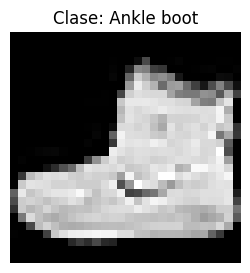

In [5]:
plt.figure(figsize=(3,3))
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Clase: {class_names[y_train[0]]}")
plt.axis("off")
plt.show()

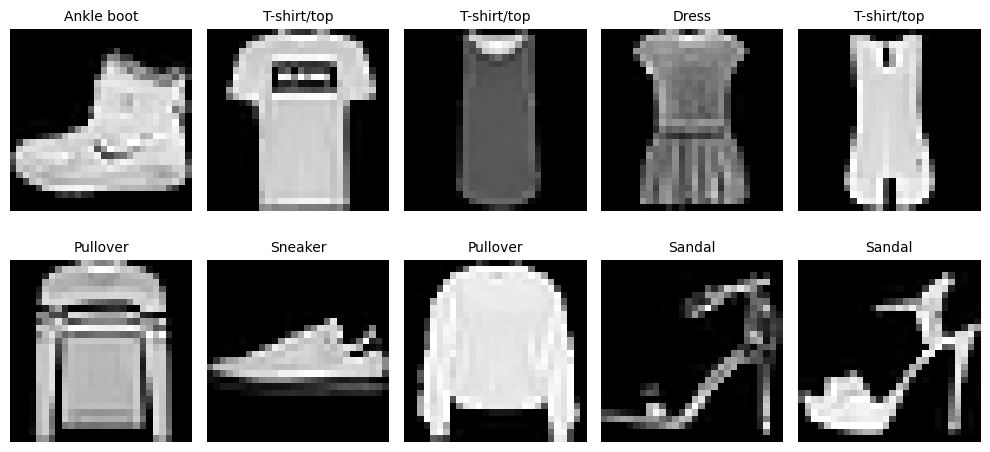

In [6]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Preprocesamiento

Para entrenar una red neuronal, normalmente conviene hacer dos cosas:

1. **Normalizar** los valores de los píxeles, para que queden entre 0 y 1.
2. **Agregar la dimensión de canal**, porque una CNN espera entradas con la forma:

`(alto, ancho, canales)`

En este caso, como las imágenes son en escala de grises, el número de canales será **1**.

In [7]:
# Normalizar imágenes a valores entre 0 y 1
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

print("Nuevo valor mínimo:", X_train.min())
print("Nuevo valor máximo:", X_train.max())

Nuevo valor mínimo: 0.0
Nuevo valor máximo: 1.0


In [8]:
# Agregar dimensión de canal: (28, 28) -> (28, 28, 1)
X_train_cnn = np.expand_dims(X_train, axis=-1)
X_test_cnn  = np.expand_dims(X_test, axis=-1)

print("X_train_cnn shape:", X_train_cnn.shape)
print("X_test_cnn shape: ", X_test_cnn.shape)

X_train_cnn shape: (60000, 28, 28, 1)
X_test_cnn shape:  (10000, 28, 28, 1)


### ¿Por qué hacemos este reshape?

Una CNN no recibe la imagen como un vector, sino como un **tensor**.

En este caso:
- antes: cada imagen tenía forma `28 x 28`
- ahora: cada imagen tiene forma `28 x 28 x 1`

El `1` corresponde al número de canales.  
Como Fashion-MNIST está en escala de grises, usamos un solo canal.

In [9]:
print("Shape de una imagen original:     ", X_train[0].shape)
print("Shape de una imagen para la CNN:  ", X_train_cnn[0].shape)

Shape de una imagen original:      (28, 28)
Shape de una imagen para la CNN:   (28, 28, 1)


## 4. Construcción de una CNN básica

Ahora construiremos una red neuronal convolucional simple.

La arquitectura será:

- `Conv2D`
- `MaxPooling2D`
- `Flatten`
- `Dense`
- capa de salida con `softmax`

Esta red ya es suficiente para ver cómo una CNN puede clasificar imágenes de manera efectiva.

In [10]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

### Comentario sobre la arquitectura

- **Conv2D**: aprende filtros que detectan patrones locales en la imagen.
- **MaxPooling2D**: reduce el tamaño espacial y resume información importante.
- **Flatten**: transforma la salida en un vector.
- **Dense**: combina las características aprendidas para clasificar.
- **Softmax**: entrega probabilidades para las 10 clases.

## 5. Compilación del modelo

Antes de entrenar, debemos definir:
- el **optimizador**,
- la **función de pérdida**,
- y las **métricas** que queremos monitorear.

Como este es un problema de clasificación multiclase y las etiquetas están como enteros (`0,1,...,9`), usaremos:

- `adam`
- `sparse_categorical_crossentropy`
- `accuracy`

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 6. Entrenamiento del modelo

Ahora entrenaremos la CNN.

Usaremos:
- algunas épocas de entrenamiento,
- un `batch_size` razonable,
- y una fracción de los datos para **validación**.

La idea es observar no solo cómo aprende en entrenamiento, sino también cómo generaliza.

In [12]:
history = model.fit(
    X_train_cnn,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.8468 - loss: 0.4449 - val_accuracy: 0.8818 - val_loss: 0.3316
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 29ms/step - accuracy: 0.8948 - loss: 0.2984 - val_accuracy: 0.9002 - val_loss: 0.2839
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.9069 - loss: 0.2593 - val_accuracy: 0.8958 - val_loss: 0.2863
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.9165 - loss: 0.2306 - val_accuracy: 0.9082 - val_loss: 0.2534
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9247 - loss: 0.2076 - val_accuracy: 0.9067 - val_loss: 0.2631


## 7. Curvas de entrenamiento

Una vez entrenado el modelo, conviene visualizar:
- la **accuracy** en entrenamiento y validación,
- la **loss** en entrenamiento y validación.

Estas curvas nos ayudan a entender si el modelo está aprendiendo bien y si hay señales de sobreajuste.

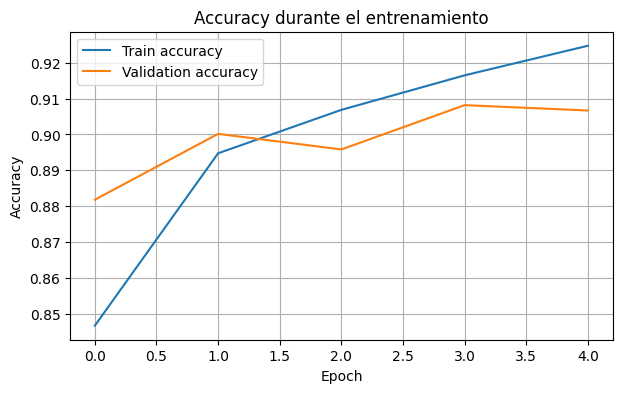

In [13]:
plt.figure(figsize=(7,4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

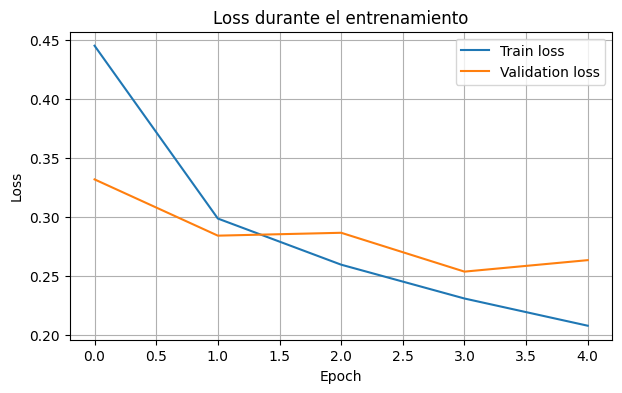

In [14]:
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

## 8. Evaluación en el conjunto de test

Ahora evaluaremos el modelo sobre datos no vistos durante el entrenamiento.

Esto nos da una estimación más realista del desempeño del modelo.

In [15]:
test_loss, test_acc = model.evaluate(X_test_cnn, y_test, verbose=0)

print("Test loss:    ", test_loss)
print("Test accuracy:", test_acc)

Test loss:     0.2767315208911896
Test accuracy: 0.8999999761581421


## 9. Predicciones del modelo

Además de mirar la accuracy global, es útil inspeccionar algunas predicciones individuales.

Así podemos ver:
- qué clases reconoce bien el modelo,
- y en qué casos se equivoca.

In [16]:
y_prob = model.predict(X_test_cnn, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print("Primeras 10 predicciones:", y_pred[:10])
print("Primeras 10 etiquetas reales:", y_test[:10])

Primeras 10 predicciones: [9 2 1 1 6 1 4 6 5 7]
Primeras 10 etiquetas reales: [9 2 1 1 6 1 4 6 5 7]


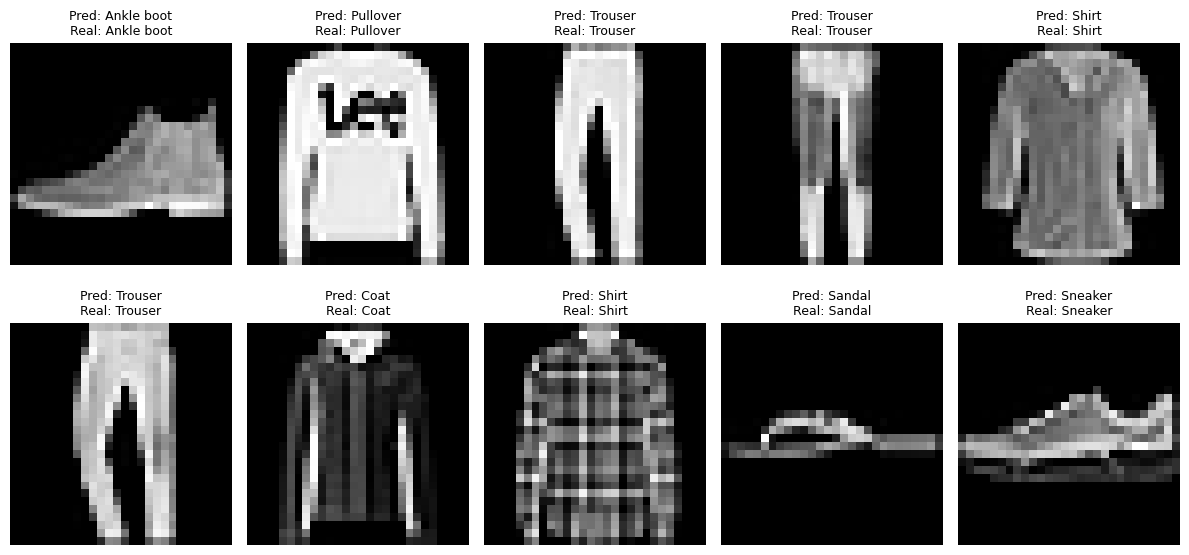

In [17]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    pred_label = class_names[y_pred[i]]
    true_label = class_names[y_test[i]]
    plt.title(f"Pred: {pred_label}\nReal: {true_label}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Comentario

En algunos casos, la red acierta con bastante confianza.  
En otros, puede confundirse entre clases visualmente parecidas, por ejemplo prendas con forma similar.

Esto es normal: aunque una CNN suele funcionar mejor que un MLP básico en imágenes, sigue cometiendo errores.

Número de errores en test: 1000


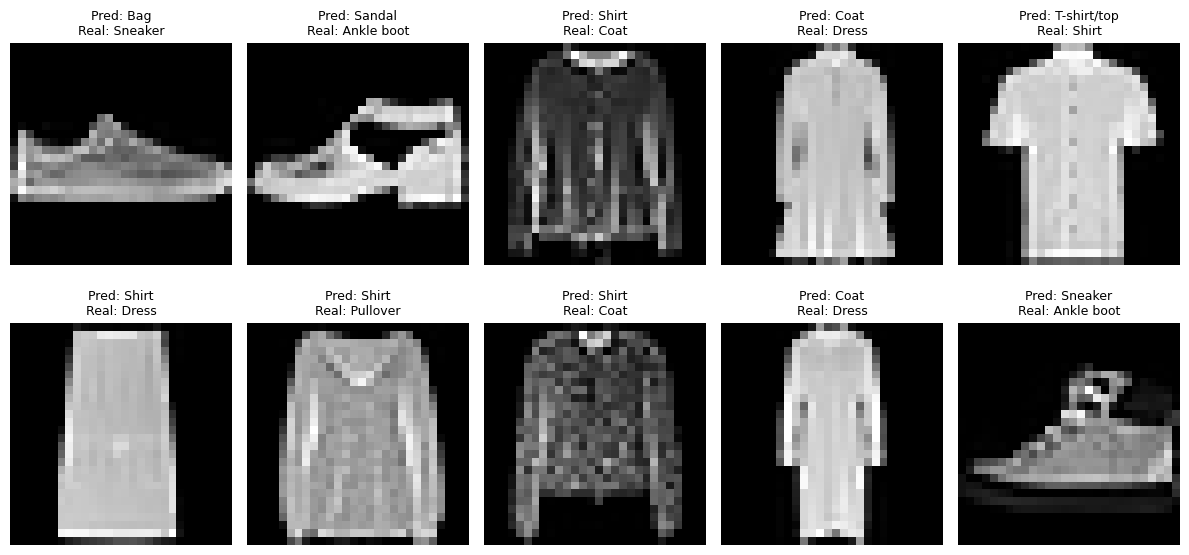

In [18]:
wrong_idx = np.where(y_pred != y_test)[0]

print("Número de errores en test:", len(wrong_idx))

plt.figure(figsize=(12,6))

for i, idx in enumerate(wrong_idx[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx], cmap="gray")
    pred_label = class_names[y_pred[idx]]
    true_label = class_names[y_test[idx]]
    plt.title(f"Pred: {pred_label}\nReal: {true_label}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 10. Cierre

En este notebook vimos cómo:

- representar imágenes como tensores,
- construir una CNN básica en Keras,
- entrenarla sobre un problema de clasificación multiclase,
- y evaluar su desempeño en datos no vistos.

### Idea central
A diferencia de una red densa, una CNN aprovecha mejor la estructura espacial de las imágenes.

En el siguiente notebook compararemos más directamente una **red densa (MLP)** con una **CNN** sobre el mismo problema.